# EDA — ISIC 2018

Análise exploratória leve do dataset **ISIC 2018** (dermatoscopia), cobrindo cada etapa:
`raw/` → `processed_128/`.

Objetivo: quantidade total de dados em cada etapa, balanceamento de classes, características das
imagens e alguns exemplos.

**Leia antes:** `data/ISIC_2018/PAPER_NOTES.md`. O ponto central é que os dois desafios do ISIC 2018
são **conjuntos de imagens disjuntos** — nenhuma imagem tem máscara *e* rótulo. Este notebook
demonstra isso a partir do dado, e não do paper.

O notebook é **independente do `src/config.yaml` ativo**: fixa `dataset='ISIC_2018'`.

In [1]:
import os, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'src' / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print('repo root:', ROOT)

%matplotlib inline

import cv2
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from src.dataset import paths

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 140)

config = yaml.safe_load(open('src/config.yaml'))
data_cfg = dict(config['data'], dataset='ISIC_2018', variant='processed_128')

# Nomes completos das 7 classes do HAM10000 (a ordem vem do GT csv, não do paper - ver PAPER_NOTES)
CLASS_NAMES = {
    'NV': 'Melanocytic nevi', 'MEL': 'Melanoma', 'BKL': 'Benign keratosis',
    'BCC': 'Basal cell carcinoma', 'AKIEC': 'Actinic keratoses',
    'VASC': 'Vascular lesions', 'DF': 'Dermatofibroma',
}

print('dataset :', paths.dataset_dir(data_cfg))
print('variant :', paths.processed_dir(data_cfg))

repo root: /home/lucas/fed_multi_task_breast_cancer


dataset : data/ISIC_2018
variant : data/ISIC_2018/processed_128


## 1. Quantidade de dados em cada etapa

In [2]:
raw = paths.raw_dir(data_cfg)

def n_files(folder, pattern):
    d = raw / folder
    inner = d / folder
    d = inner if inner.is_dir() else d
    return len(list(d.glob(pattern)))

raw_rows = [
    ('seg', 'train', 'Task1-2_Training_Input', 'ISIC2018_Task1-2_Training_Input', '*.jpg',
     'ISIC2018_Task1_Training_GroundTruth', '*.png'),
    ('seg', 'val', 'Task1-2_Validation_Input', 'ISIC2018_Task1-2_Validation_Input', '*.jpg',
     'ISIC2018_Task1_Validation_GroundTruth', '*.png'),
    ('seg', 'test', 'Task1-2_Test_Input', 'ISIC2018_Task1-2_Test_Input', '*.jpg',
     'ISIC2018_Task1_Test_GroundTruth', '*.png'),
    ('cls', 'train', 'Task3_Training_Input', 'ISIC2018_Task3_Training_Input', '*.jpg',
     'ISIC2018_Task3_Training_GroundTruth', '*.csv'),
    ('cls', 'val', 'Task3_Validation_Input', 'ISIC2018_Task3_Validation_Input', '*.jpg',
     'ISIC2018_Task3_Validation_GroundTruth', '*.csv'),
    ('cls', 'test', 'Task3_Test_Input', 'ISIC2018_Task3_Test_Input', '*.jpg',
     'ISIC2018_Task3_Test_GroundTruth', '*.csv'),
]

rows = []
for task, split, label, img_folder, img_pat, gt_folder, gt_pat in raw_rows:
    n_img = n_files(img_folder, img_pat)
    if gt_pat == '*.csv':
        d = raw / gt_folder / gt_folder
        d = d if d.is_dir() else raw / gt_folder
        n_gt = len(pd.read_csv(list(d.glob('*.csv'))[0]))
        gt_kind = 'rótulos (csv)'
    else:
        n_gt = n_files(gt_folder, gt_pat)
        gt_kind = 'máscaras'
    rows.append({'task': task, 'split': split, 'pasta': label,
                 'imagens': n_img, 'ground truth': n_gt, 'tipo GT': gt_kind})

raw_counts = pd.DataFrame(rows)
display(raw_counts)
print(f"\nTotal de imagens no raw: {raw_counts.imagens.sum()}"
      f"  (seg {raw_counts[raw_counts.task=='seg'].imagens.sum()}"
      f" + cls {raw_counts[raw_counts.task=='cls'].imagens.sum()})")

,task,split,pasta,imagens,ground truth,tipo GT
0,seg,train,Task1-2_Training_Input,2594,2594,máscaras
1,seg,val,Task1-2_Validation_Input,100,100,máscaras
2,seg,test,Task1-2_Test_Input,1000,1000,máscaras
3,cls,train,Task3_Training_Input,10015,10015,rótulos (csv)
4,cls,val,Task3_Validation_Input,193,193,rótulos (csv)
5,cls,test,Task3_Test_Input,1512,1512,rótulos (csv)



Total de imagens no raw: 15414  (seg 3694 + cls 11720)


> As pastas do release oficial vêm **duplamente aninhadas** (`X/X/arquivos`) e cada uma carrega
> `ATTRIBUTION.txt` e `LICENSE.txt` — por isso o preprocessing filtra por extensão explícita em vez
> de listar o diretório.
>
> O **Task 2** (12.970 máscaras de atributos dermatoscópicos) existe no `raw/` mas está fora do
> escopo: é outra tarefa (detecção de 5 atributos), não segmentação de lesão.

In [3]:
mapping = pd.read_csv(paths.mapping_file(data_cfg))

etapas = pd.DataFrame([
    {'etapa': '1. raw/ Task 1 (segmentação)', 'linhas': int(raw_counts[raw_counts.task=='seg'].imagens.sum()),
     'observação': 'imagens + máscaras, SEM rótulo de classe'},
    {'etapa': '1. raw/ Task 3 (classificação)', 'linhas': int(raw_counts[raw_counts.task=='cls'].imagens.sum()),
     'observação': 'imagens + rótulos, SEM máscara'},
    {'etapa': '2. processed_128/ (mapping.csv)', 'linhas': len(mapping),
     'observação': f"{(mapping.task=='seg').sum()} seg + {(mapping.task=='cls').sum()} cls, 128x128 RGB"},
    {'etapa': '3. partição federada', 'linhas': 0,
     'observação': 'ainda não existe — federated_partition estratifica por `class` e precisa de design próprio'},
])
display(etapas)

print('Colunas do mapping.csv:')
print(' ', list(mapping.columns))

,etapa,linhas,observação
0,1. raw/ Task 1 (segmentação),3694,"imagens + máscaras, SEM rótulo de classe"
1,1. raw/ Task 3 (classificação),11720,"imagens + rótulos, SEM máscara"
2,2. processed_128/ (mapping.csv),15414,"3694 seg + 11720 cls, 128x128 RGB"
3,3. partição federada,0,ainda não existe — federated_partition estrati...


Colunas do mapping.csv:
  ['img_path', 'mask_path', 'class', 'id', 'task', 'official_split', 'lesion_id', 'dim1', 'dim2', 'tumor_pixels', 'y_max', 'y_min', 'x_max', 'x_min', 'y_size', 'x_size']


## 2. A disjunção seg / cls

Esta é a característica que define o dataset. Vamos medir, não presumir.

Task 1 (seg):   3694 imagens | IDs      0 ..  36347
Task 3 (cls):  11720 imagens | IDs  24306 ..  36064

>>> INTERSEÇÃO: 0 imagens têm máscara E rótulo

Consequências:
  - linhas seg sem `class`     : 3694/3694
  - linhas cls sem `mask_path` : 11720/11720

Cuidado ao ler o min..max acima: o intervalo do seg CONTÉM o do cls, mas isso não
significa mistura. Nenhum id de seg cai dentro da faixa ocupada pelo cls:
  seg, bloco baixo :  3436 imagens | ids      0 ..  24191
  cls, bloco único : 11720 imagens | ids  24306 ..  36064
  seg, bloco alto  :   258 imagens | ids  36066 ..  36347
  -> ids de seg DENTRO da faixa do cls: 0
  -> lacunas que separam os blocos: 24191->24306 e 36064->36066


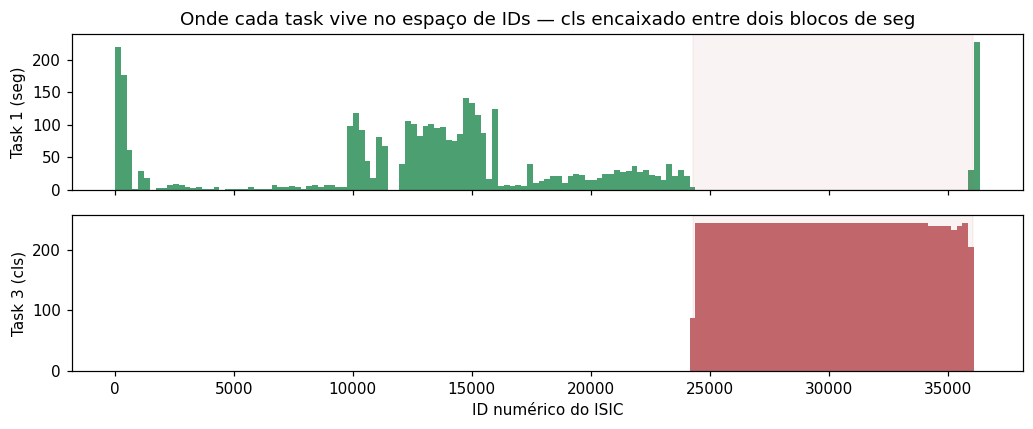

Faixa de ids por task x split (é seg/val e seg/test que puxam os ids altos):


n  id_min  id_max
task official_split                       
cls  test             1512   34524   36064
     train           10015   24306   34320
     val               193   34321   34523
seg  test             1000   12169   36347
     train            2594       0   16072
     val               100   12255   36333

In [4]:
seg = mapping[mapping.task == 'seg']
cls = mapping[mapping.task == 'cls']

print(f"Task 1 (seg): {len(seg):>6} imagens | IDs {seg.id.min():>6} .. {seg.id.max():>6}")
print(f"Task 3 (cls): {len(cls):>6} imagens | IDs {cls.id.min():>6} .. {cls.id.max():>6}")
print()
overlap = set(seg.id) & set(cls.id)
print(f">>> INTERSEÇÃO: {len(overlap)} imagens têm máscara E rótulo")
print()
print('Consequências:')
print(f"  - linhas seg sem `class`     : {seg['class'].isna().sum()}/{len(seg)}")
print(f"  - linhas cls sem `mask_path` : {cls.mask_path.isna().sum()}/{len(cls)}")
print()
print('Cuidado ao ler o min..max acima: o intervalo do seg CONTÉM o do cls, mas isso não')
print('significa mistura. Nenhum id de seg cai dentro da faixa ocupada pelo cls:')
lo, hi = seg[seg.id < cls.id.min()], seg[seg.id > cls.id.max()]
dentro = ((seg.id >= cls.id.min()) & (seg.id <= cls.id.max())).sum()
print(f"  seg, bloco baixo : {len(lo):>5} imagens | ids {lo.id.min():>6} .. {lo.id.max():>6}")
print(f"  cls, bloco único : {len(cls):>5} imagens | ids {cls.id.min():>6} .. {cls.id.max():>6}")
print(f"  seg, bloco alto  : {len(hi):>5} imagens | ids {hi.id.min():>6} .. {hi.id.max():>6}")
print(f"  -> ids de seg DENTRO da faixa do cls: {dentro}")
print(f"  -> lacunas que separam os blocos: {lo.id.max()}->{cls.id.min()} e {cls.id.max()}->{hi.id.min()}")

fig, ax = plt.subplots(2, 1, figsize=(9.5, 4), sharex=True)
bins = np.linspace(0, max(seg.id.max(), cls.id.max()), 150)
ax[0].hist(seg.id, bins=bins, color='#4C9F70'); ax[0].set_ylabel('Task 1 (seg)')
ax[0].set_title('Onde cada task vive no espaço de IDs — cls encaixado entre dois blocos de seg')
ax[1].hist(cls.id, bins=bins, color='#C1666B'); ax[1].set_ylabel('Task 3 (cls)')
ax[1].set_xlabel('ID numérico do ISIC')
for a in ax:
    a.axvspan(cls.id.min(), cls.id.max(), color='#C1666B', alpha=.08)
plt.tight_layout(); plt.show()

print('Faixa de ids por task x split (é seg/val e seg/test que puxam os ids altos):')
display(mapping.groupby(['task', 'official_split']).agg(
    n=('id', 'size'), id_min=('id', 'min'), id_max=('id', 'max')))

**Nenhuma imagem tem as duas supervisões.** Um modelo multi-task convencional (uma imagem → máscara
+ rótulo) não pode ser treinado no ISIC 2018 direto da caixa.

Repare na sutileza do `min..max`: o intervalo do seg (0..36347) **contém** o do cls (24306..36064),
o que dá a impressão de mistura. Não há. O seg vive em **dois blocos** — um abaixo e um acima do cls —
e nenhum id de seg cai dentro da faixa do cls. Quem puxa os ids altos do seg é o `seg/val` e o
`seg/test`; olhando só o *training* (o recorte que o paper de referência usou), o seg é um bloco só,
em 0..16072.

A garantia dura não vem de olhar intervalos, e sim do preprocessing: ele aborta se algum `id` se
repetir nas 15.414 linhas, e um id compartilhado entre as duas tasks seria exatamente uma duplicata.

Para o **FedPer** isso não é bloqueio: cada cliente tem exatamente **uma** tarefa, então pools
disjuntos são naturais — clientes `seg` pegam o Task 1, clientes `cls` pegam o Task 3.

Para o **MTL centralizado** (`training_centralized.py`) é bloqueio: ele precisa de imagem + máscara +
rótulo na mesma linha, e não existe tal linha.

## 3. Balanceamento de classes

,nome,imagens,proporção
NV,Melanocytic nevi,7737,0.6602
BKL,Benign keratosis,1338,0.1142
MEL,Melanoma,1305,0.1113
BCC,Basal cell carcinoma,622,0.0531
AKIEC,Actinic keratoses,378,0.0323
VASC,Vascular lesions,180,0.0154
DF,Dermatofibroma,160,0.0137
TOTAL,,11720,1.0000


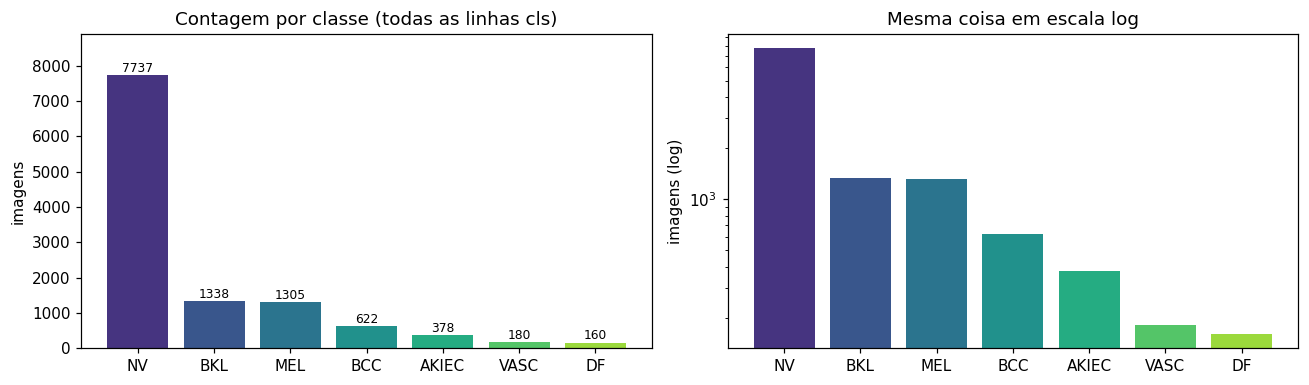

Razão maior/menor: 48.4x  (NV=7737 vs DF=160)
Classe majoritária NV sozinha: 66.0% do dataset


In [5]:
dist = cls['class'].value_counts()
bal = pd.DataFrame({
    'nome': [CLASS_NAMES[c] for c in dist.index],
    'imagens': dist.values,
    'proporção': (dist.values / dist.sum()).round(4),
})
bal.index = dist.index
bal.loc['TOTAL'] = ['', dist.sum(), 1.0]
display(bal)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
cmap = plt.cm.viridis(np.linspace(.15, .85, len(dist)))
ax[0].bar(dist.index, dist.values, color=cmap)
for i, v in enumerate(dist.values):
    ax[0].text(i, v + 90, str(v), ha='center', fontsize=8)
ax[0].set_title('Contagem por classe (todas as linhas cls)'); ax[0].set_ylabel('imagens')
ax[0].set_ylim(0, dist.max() * 1.15)

ax[1].bar(dist.index, dist.values, color=cmap); ax[1].set_yscale('log')
ax[1].set_title('Mesma coisa em escala log'); ax[1].set_ylabel('imagens (log)')
plt.tight_layout(); plt.show()

print(f"Razão maior/menor: {dist.max()/dist.min():.1f}x  "
      f"({dist.idxmax()}={dist.max()} vs {dist.idxmin()}={dist.min()})")
print(f"Classe majoritária NV sozinha: {dist.max()/dist.sum()*100:.1f}% do dataset")

Desbalanceamento **severo** — cerca de 48x entre a maior e a menor classe (58x se olhar só o split
train), e `NV` sozinha é ~66% do dataset. Para comparação, o Curated BUSI é ~3.5x.

Isso importa muito na prática: um classificador que sempre responde `NV` já acerta 67%. Acurácia
simples é uma métrica enganosa aqui — macro-F1 e balanced accuracy são obrigatórias. O paper de
referência usa pesos de classe balanceados por frequência inversa (sklearn `'balanced'`) por
exatamente esse motivo.

> **Nota:** a Tabela 2 do paper de referência troca os nomes de três classes (afirma que lesões
> vasculares são 67% de uma base de dermatoscopia — são nevos melanocíticos). Os números acima vêm
> do GT csv oficial. Ver `PAPER_NOTES.md` §5.3.

## 4. Distribuição por task e split oficial

In [6]:
ct = pd.crosstab(mapping.task, mapping.official_split, margins=True, margins_name='TOTAL')
display(ct[['train', 'val', 'test', 'TOTAL']])

print('\nBalanceamento de classe dentro de cada split oficial (linhas cls):')
by_split = pd.crosstab(cls['class'], cls.official_split)
by_split_pct = (by_split / by_split.sum()).round(3)
display(pd.concat({'contagem': by_split, 'proporção': by_split_pct}, axis=1))

official_split,train,val,test,TOTAL
task,,,,
cls,10015,193,1512,11720
seg,2594,100,1000,3694
TOTAL,12609,293,2512,15414



Balanceamento de classe dentro de cada split oficial (linhas cls):


contagem            proporção              
official_split     test train  val      test  train    val
class                                                     
AKIEC                43   327    8     0.028  0.033  0.041
BCC                  93   514   15     0.062  0.051  0.078
BKL                 217  1099   22     0.144  0.110  0.114
DF                   44   115    1     0.029  0.011  0.005
MEL                 171  1113   21     0.113  0.111  0.109
NV                  909  6705  123     0.601  0.669  0.637
VASC                 35   142    3     0.023  0.014  0.016

Os splits oficiais preservam aproximadamente a mesma distribuição de classes — o desbalanceamento
não é um artefato do split, é do dataset.

## 5. `lesion_id` — risco de vazamento

Múltiplas fotos da **mesma lesão física** não podem cair em treino e teste ao mesmo tempo.

Imagens (cls/train)        : 10015
Lesões únicas              : 7470
Média de imagens por lesão : 1.34   (máx 6)
Lesões com >1 imagem       : 1956 (26.2% das lesões)
Imagens em lesão multi-foto: 4501 (44.9% das imagens)

Cobertura do lesion_id (só o Task 3 training é publicado):


linhas  com lesion_id
task official_split                       
cls  test              1512              0
     train            10015          10015
     val                193              0
seg  test              1000              0
     train             2594              0
     val                100              0

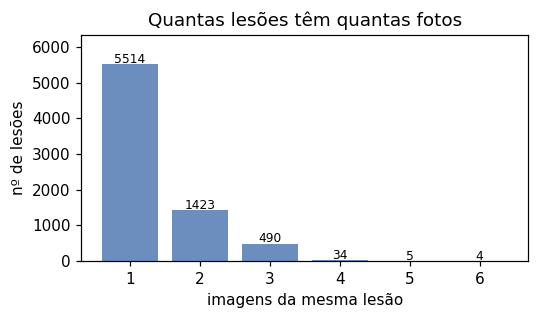

In [7]:
tr = cls[cls.official_split == 'train']
vc = tr.lesion_id.value_counts()

print(f"Imagens (cls/train)        : {len(tr)}")
print(f"Lesões únicas              : {tr.lesion_id.nunique()}")
print(f"Média de imagens por lesão : {vc.mean():.2f}   (máx {vc.max()})")
print(f"Lesões com >1 imagem       : {(vc>1).sum()} ({(vc>1).sum()/len(vc)*100:.1f}% das lesões)")
print(f"Imagens em lesão multi-foto: {vc[vc>1].sum()} ({vc[vc>1].sum()/len(tr)*100:.1f}% das imagens)")
print()
print('Cobertura do lesion_id (só o Task 3 training é publicado):')
cov = mapping.groupby(['task', 'official_split']).apply(
    lambda g: pd.Series({'linhas': len(g), 'com lesion_id': int(g.lesion_id.notna().sum())}))
display(cov)

fig, ax = plt.subplots(figsize=(5, 3))
counts = vc.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color='#6C8EBF')
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, str(v), ha='center', fontsize=8)
ax.set_xlabel('imagens da mesma lesão'); ax.set_ylabel('nº de lesões')
ax.set_title('Quantas lesões têm quantas fotos'); ax.set_ylim(0, counts.max()*1.15)
plt.tight_layout(); plt.show()

**45% das imagens dividem lesão com outra.** Um split aleatório por imagem colocaria quase-duplicatas
da mesma lesão nos dois lados — inflando a métrica de teste.

É estruturalmente o mesmo problema que o Curated BUSI resolve removendo 330 duplicatas via SSIM.
Portanto: **splitar por `lesion_id`, nunca por `id`**.

A limitação: o arquivo de agrupamento só é publicado para o Task 3 *training*. Val e test oficiais
não têm `lesion_id`, então não dá para verificar vazamento entre eles.

## 6. Características das imagens

In [8]:
print('Dimensões após preprocessing:', mapping[['dim1','dim2']].drop_duplicates().to_dict('records'))
img = cv2.imread(mapping.img_path.iloc[0], cv2.IMREAD_UNCHANGED)
print('Canais                      :', img.shape, '(RGB, ao contrário do BUSI que é grayscale)')
print()

# Resolução original: heterogênea no Task 1, uniforme no Task 3
rng = np.random.default_rng(0)
for task, folder in [('seg', 'ISIC2018_Task1-2_Training_Input'), ('cls', 'ISIC2018_Task3_Training_Input')]:
    d = raw / folder / folder
    files = sorted(d.glob('*.jpg'))
    sample = rng.choice(np.array(files, dtype=object), 200, replace=False)
    sizes = {}
    for f in sample:
        im = cv2.imread(str(f))
        sizes[(im.shape[1], im.shape[0])] = sizes.get((im.shape[1], im.shape[0]), 0) + 1
    top = sorted(sizes.items(), key=lambda kv: -kv[1])[:3]
    print(f"raw {task}: {len(sizes)} resoluções distintas em 200 amostras | mais comuns: "
          + ', '.join(f'{w}x{h} ({n})' for (w, h), n in top))

Dimensões após preprocessing: [{'dim1': 128, 'dim2': 128}]
Canais                      : (128, 128, 3) (RGB, ao contrário do BUSI que é grayscale)



raw seg: 44 resoluções distintas em 200 amostras | mais comuns: 4288x2848 (41), 1024x768 (39), 3008x2000 (34)


raw cls: 1 resoluções distintas em 200 amostras | mais comuns: 600x450 (200)


O Task 1 é **heterogêneo** (dezenas de resoluções e proporções); o Task 3 é uniformemente 600x450.

O preprocessing esmaga tudo para 128x128 (`PRESERVE_ASPECT = False`), o que distorce a proporção —
constante no Task 3, variável no Task 1. Como assimetria é critério diagnóstico em lesão de pele
(o "A" do ABCD), isso tem custo real; a constante existe para ser trocada por padding se quiser.

,tumor_pixels,y_size,x_size
count,3694.0,3694.0,3694.0
mean,3820.9,72.8,59.3
std,3496.5,32.5,31.7
min,39.0,10.0,5.0
25%,1075.5,46.0,33.0
50%,2697.0,71.0,54.0
75%,5584.8,99.0,81.8
max,16384.0,128.0,128.0


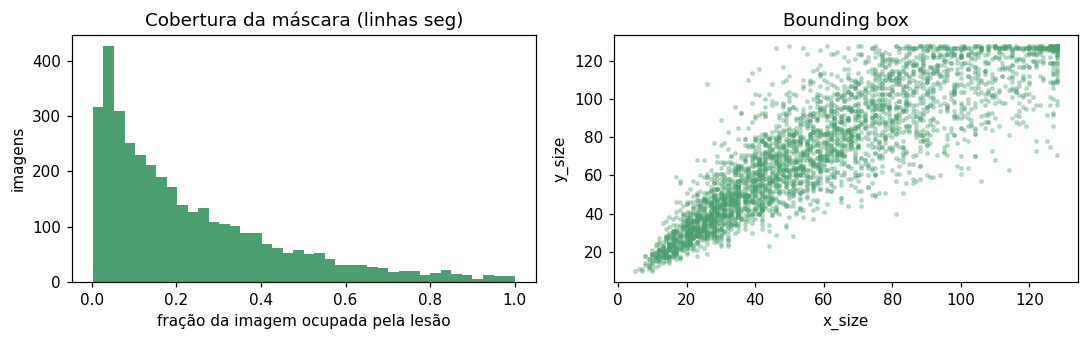

Máscaras vazias: 0  (esperado 0 — toda imagem do Task 1 tem lesão)
Cobertura média: 23.3% da imagem  (BUSI fica em torno de 5-8% — lesões de pele ocupam muito mais quadro)


In [9]:
seg_stats = seg[['tumor_pixels', 'y_size', 'x_size']].describe().round(1)
display(seg_stats)

frac = seg.tumor_pixels / (seg.dim1 * seg.dim2)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(frac, bins=40, color='#4C9F70')
ax[0].set_xlabel('fração da imagem ocupada pela lesão'); ax[0].set_ylabel('imagens')
ax[0].set_title('Cobertura da máscara (linhas seg)')
ax[1].scatter(seg.x_size, seg.y_size, s=5, alpha=.3, color='#4C9F70')
ax[1].set_xlabel('x_size'); ax[1].set_ylabel('y_size'); ax[1].set_title('Bounding box')
plt.tight_layout(); plt.show()

print(f"Máscaras vazias: {(seg.tumor_pixels == 0).sum()}  (esperado 0 — toda imagem do Task 1 tem lesão)")
print(f"Cobertura média: {frac.mean()*100:.1f}% da imagem  "
      f"(BUSI fica em torno de 5-8% — lesões de pele ocupam muito mais quadro)")

## 7. Exemplos

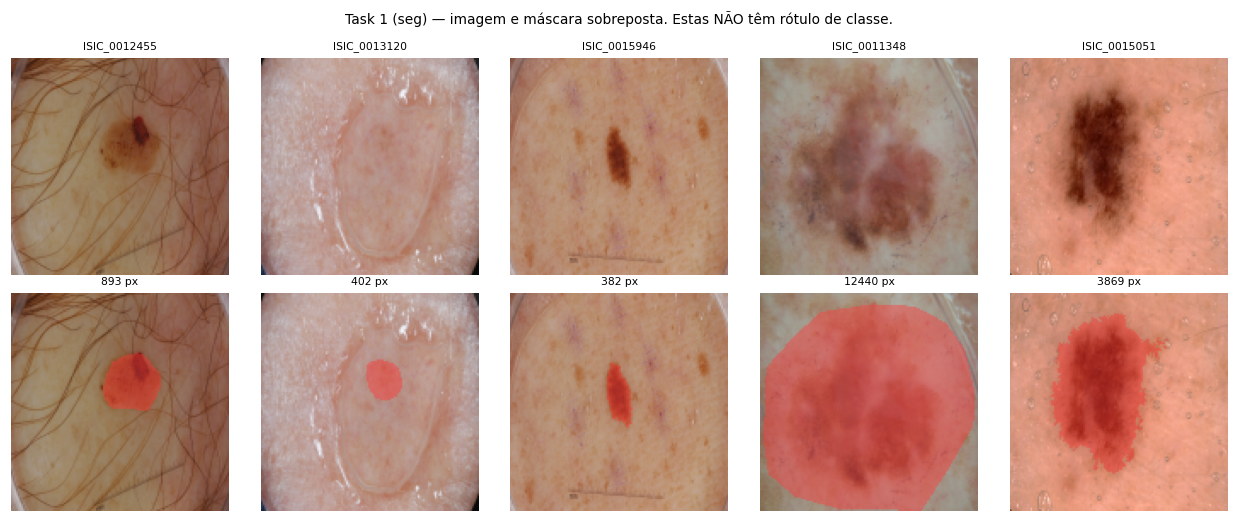

In [10]:
rng = np.random.default_rng(7)
N = 5
picks = rng.choice(seg.index.values, N, replace=False)
fig, axes = plt.subplots(2, N, figsize=(2.3*N, 4.8))
for c, idx in enumerate(picks):
    row = seg.loc[idx]
    img = cv2.cvtColor(cv2.imread(row.img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row.mask_path, 0)
    axes[0, c].imshow(img); axes[0, c].set_title(f"ISIC_{int(row.id):07d}", fontsize=7)
    over = img.copy()
    over[mask > 0] = (0.55*over[mask > 0] + 0.45*np.array([255, 60, 60])).astype(np.uint8)
    axes[1, c].imshow(over); axes[1, c].set_title(f"{int(row.tumor_pixels)} px", fontsize=7)
    axes[0, c].axis('off'); axes[1, c].axis('off')
plt.suptitle('Task 1 (seg) — imagem e máscara sobreposta. Estas NÃO têm rótulo de classe.', fontsize=9)
plt.tight_layout(); plt.show()

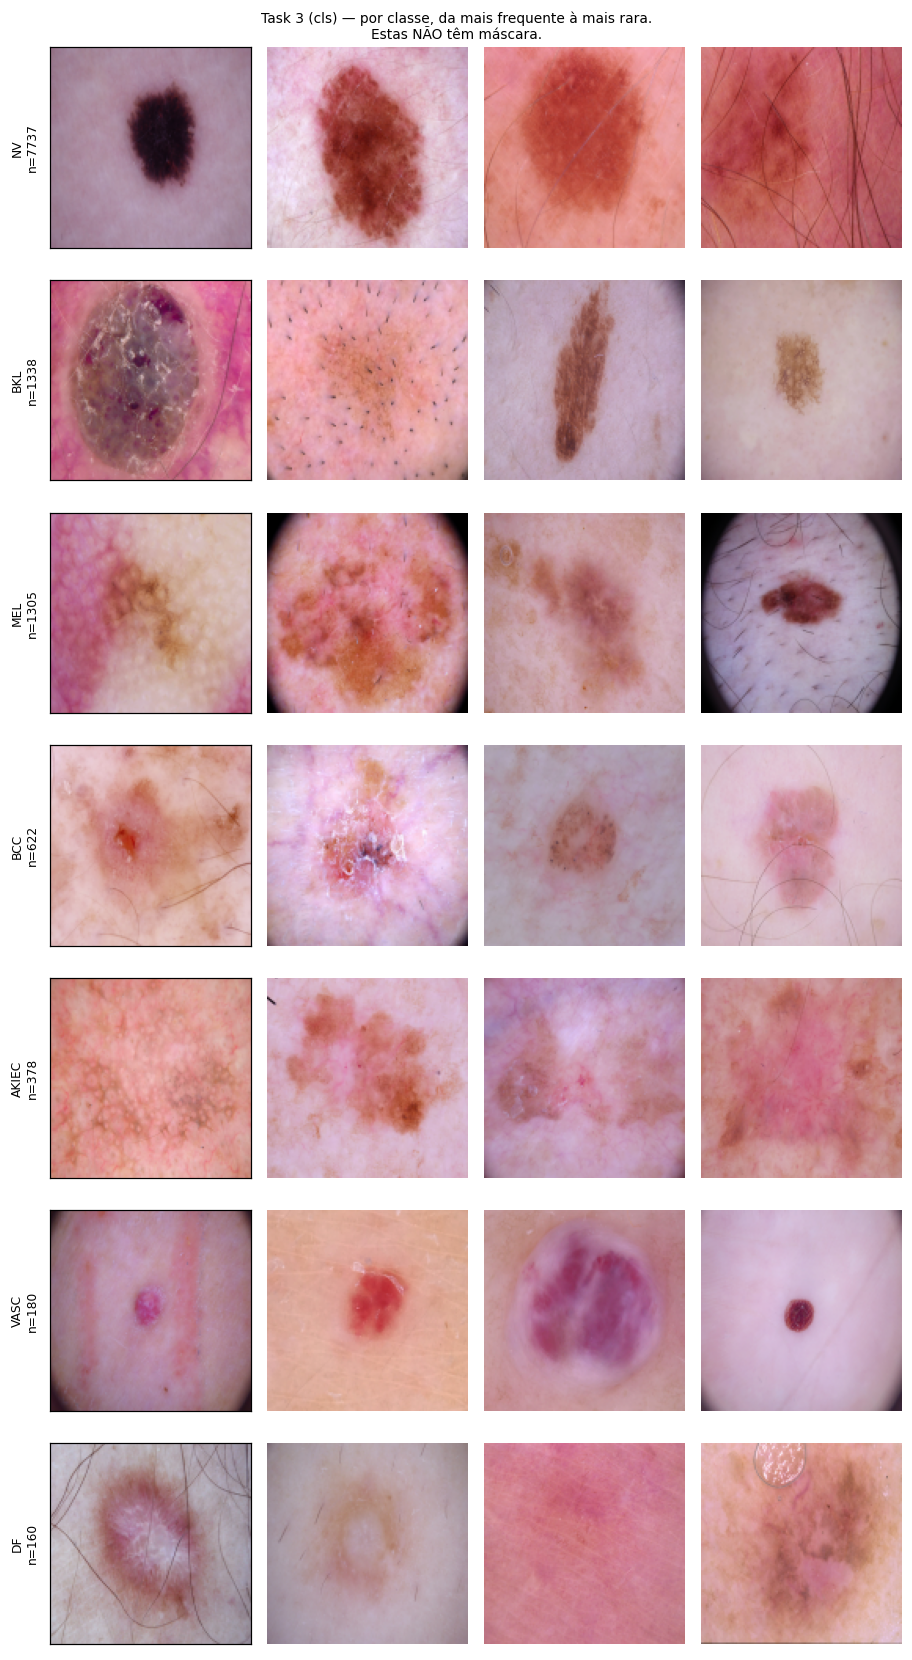

In [11]:
order = dist.index.tolist()   # da classe mais frequente para a mais rara
N = 4
fig, axes = plt.subplots(len(order), N, figsize=(2.1*N, 2.2*len(order)))
for r, c_name in enumerate(order):
    sub = cls[cls['class'] == c_name]
    picks = rng.choice(sub.index.values, N, replace=False)
    for c, idx in enumerate(picks):
        row = cls.loc[idx]
        axes[r, c].imshow(cv2.cvtColor(cv2.imread(row.img_path), cv2.COLOR_BGR2RGB))
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_ylabel(c_name)
            axes[r, c].axis('on'); axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
            axes[r, c].set_ylabel(f"{c_name}\nn={len(sub)}", fontsize=8)
plt.suptitle('Task 3 (cls) — por classe, da mais frequente à mais rara.\nEstas NÃO têm máscara.',
             fontsize=9)
plt.tight_layout(); plt.show()

## 8. Resumo

In [12]:
print(f"""
ISIC 2018
---------
raw/ Task 1 (seg)   {len(seg)} imagens + máscaras, SEM rótulo   (IDs {seg.id.min()}..{seg.id.max()})
raw/ Task 3 (cls)   {len(cls)} imagens + rótulos, SEM máscara   (IDs {cls.id.min()}..{cls.id.max()})
INTERSEÇÃO          {len(overlap)} imagens  <- nenhuma imagem tem as duas supervisões

processed_128/      {len(mapping)} linhas, 128x128 RGB
                    colunas extras: task, official_split, lesion_id
                    colunas de máscara = NaN nas linhas cls (NaN != 0; 0 seria "máscara vazia")

Balanceamento       7 classes, {dist.max()/dist.min():.0f}x entre maior e menor
                    NV sozinha = {dist.max()/dist.sum()*100:.1f}% -> acurácia simples é enganosa,
                    usar macro-F1 / balanced accuracy
Vazamento           {vc[vc>1].sum()/len(tr)*100:.1f}% das imagens cls/train dividem lesão com outra
                    -> splitar por lesion_id, nunca por id
                    lesion_id só existe no Task 3 training

Serve para          FedPer (1 tarefa por cliente -> pools disjuntos são naturais)
NÃO serve para      MTL centralizado (precisa de imagem+máscara+rótulo na mesma linha)
""")


ISIC 2018
---------
raw/ Task 1 (seg)   3694 imagens + máscaras, SEM rótulo   (IDs 0..36347)
raw/ Task 3 (cls)   11720 imagens + rótulos, SEM máscara   (IDs 24306..36064)
INTERSEÇÃO          0 imagens  <- nenhuma imagem tem as duas supervisões

processed_128/      15414 linhas, 128x128 RGB
                    colunas extras: task, official_split, lesion_id
                    colunas de máscara = NaN nas linhas cls (NaN != 0; 0 seria "máscara vazia")

Balanceamento       7 classes, 48x entre maior e menor
                    NV sozinha = 66.0% -> acurácia simples é enganosa,
                    usar macro-F1 / balanced accuracy
Vazamento           44.9% das imagens cls/train dividem lesão com outra
                    -> splitar por lesion_id, nunca por id
                    lesion_id só existe no Task 3 training

Serve para          FedPer (1 tarefa por cliente -> pools disjuntos são naturais)
NÃO serve para      MTL centralizado (precisa de imagem+máscara+rótulo na mesma linha)

